# PyTorch Tutorial

Paul J. Atzberger<br> 
<https://web.atzberger.org/>

# Optimization: SGD, Adam, and the Training Loop

Training a machine learning model (neural network) typically means finding the parameter values that minimize a loss function. PyTorch makes this possible through two mechanisms:

- **Autograd:** automatic computation of gradients via backpropagation (algorithm is similar to performing the chain-rule in calculus) (see our [slides posted](https://web.atzberger.org/teaching)).
- **`torch.optim`:** a collection of gradient-based optimizers.

In this notebook you will:
1. Understand autograd and `loss.backward()`
2. See the four-step training loop
3. Compare SGD, Adam, and AdamW
4. Use learning-rate schedulers
5. Train a toy model to convergence

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

---
## Autograd: Automatic Differentiation

When `requires_grad=True`, PyTorch records every operation on a tensor so it can
later compute derivatives with respect to that tensor. Calling `.backward()` on a
scalar loss walks that record in reverse (backpropagation) and accumulates
gradients in each tensor's `.grad` attribute.

In [2]:
# A single learnable scalar: w
w = torch.tensor(3.0, requires_grad=True)

# Define a simple function: L = (w - 5)²
# The minimum is at w = 5, and dL/dw = 2(w - 5)
L = (w - 5) ** 2

# Backpropagate: compute dL/dw
L.backward()

print(f"w           = {w.item():.1f}")
print(f"L           = {L.item():.1f}")
print(f"dL/dw       = {w.grad.item():.1f}")
print(f"Expected    = 2*(3-5) = {2*(3-5):.1f}")

w           = 3.0
L           = 4.0
dL/dw       = -4.0
Expected    = 2*(3-5) = -4.0


The `nn.Module` parameters automatically have `requires_grad=True`. You almost never need to set that flag yourself on model weights. In some cases, you may need to turn off some select parameters if they are hyper-parameters or are not trainable for other reasons.  Below gives an example of how to turn-off gradient tracking.

In [3]:
# Use torch.no_grad() to skip gradient tracking (e.g. during evaluation)
x = torch.randn(4)
with torch.no_grad():
    y = x * 2   # no computational graph is built -faster and uses less memory
    print("y.requires_grad:", y.requires_grad)  # False

y.requires_grad: False


---
## The Training Loop Structure

Most gradient-based training iterations use the following four steps:

```
1. optimizer.zero_grad()       # clear old gradients
2. loss = loss_fn(model(x), y) # forward pass
3. loss.backward()             # compute new gradients
4. optimizer.step()            # update parameters
```

Step 1 is easy to forget. PyTorch *accumulates* gradients by default, so if you
skip `zero_grad()` the gradients from multiple iterations pile up (corrupted from previous iterations). You should explicitly zero-out gradients each iteration. 

---
## Stochastic Gradient Descent (SGD)

SGD is the oldest and simplest optimizer. The update rule is:

$$w \leftarrow w - \eta \, \nabla_w \mathcal{L}$$

where $\eta$ is the **learning rate**. The $\eta$ is a crucial hyperparameter. It taken too large the training diverges and if taken too small and training is very slow to converge.

Learned weight: 1.998  (true: 2.0)
Learned bias  : 1.010   (true: 1.0)


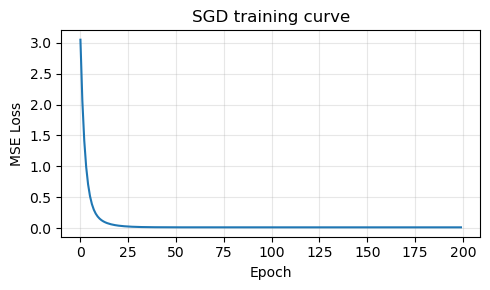

In [4]:
torch.manual_seed(42)

# Toy problem: fit a line y = 2x + 1 from noisy data
x_data = torch.linspace(-1, 1, 50).unsqueeze(1)
y_data = 2 * x_data + 1 + 0.1 * torch.randn_like(x_data)

model   = nn.Linear(1, 1)          # learn y = wx + b
loss_fn = nn.MSELoss()
optim   = torch.optim.SGD(model.parameters(), lr=0.1)

losses = []
for epoch in range(200):
    optim.zero_grad()               # step 1
    pred = model(x_data)            # step 2a
    loss = loss_fn(pred, y_data)    # step 2b
    loss.backward()                 # step 3
    optim.step()                    # step 4
    losses.append(loss.item())

print(f"Learned weight: {model.weight.item():.3f}  (true: 2.0)")
print(f"Learned bias  : {model.bias.item():.3f}   (true: 1.0)")

plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SGD training curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Adam: Adaptive Moment Estimation

Adam is the default choice for most deep-learning tasks. It maintains a
per-parameter running average of both the gradient and its square, which
effectively gives each parameter its own adaptive learning rate.

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(1st moment)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(2nd moment)}$$
$$w_t = w_{t-1} - \frac{\eta}{\sqrt{\hat v_t} + \epsilon} \hat m_t$$

Default hyperparameters (`lr=1e-3, betas=(0.9, 0.999), eps=1e-8`) work well
in a wide range of situations. It is good to be aware of the roles each of these parameters plays. In practice, usually only `lr` needs to be tuned.

In [5]:
torch.manual_seed(42)

model_adam = nn.Linear(1, 1)
optim_adam = torch.optim.Adam(model_adam.parameters(), lr=1e-2)

losses_adam = []
for epoch in range(200):
    optim_adam.zero_grad()
    loss = loss_fn(model_adam(x_data), y_data)
    loss.backward()
    optim_adam.step()
    losses_adam.append(loss.item())

print(f"Learned weight: {model_adam.weight.item():.3f}  (true: 2.0)")
print(f"Learned bias  : {model_adam.bias.item():.3f}   (true: 1.0)")

Learned weight: 1.927  (true: 2.0)
Learned bias  : 1.010   (true: 1.0)


### AdamW: Adam with Decoupled Weight Decay

For weight decay, the standard Adam algorithm applies this in an inconvenient way (it gets folded into the adaptive scaling calculations). A new method **AdamW** was introduced to fix this issue. It is currently the preferred choice for modern machine learning training. You can use it like Adam but you now pass in the desired level of `weight_decay`, instead of putting that regularization in the loss function.

In [6]:
model_adamw = nn.Linear(1, 1)
optim_adamw = torch.optim.AdamW(
    model_adamw.parameters(),
    lr=1e-2,
    weight_decay=1e-4   # L2 regularisation -penalises large weights
)

---
## Comparing Optimizers on a Basic Problem

Below we compare SGD (with momentum), Adam, and AdamW on a small two-layer
network fitting a noisy quadratic.

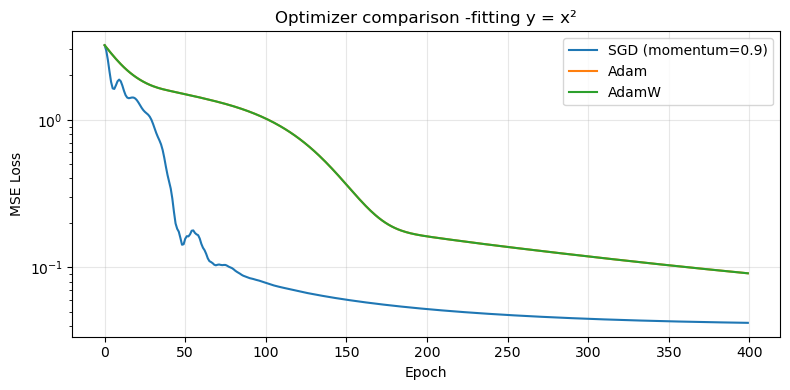

In [7]:
torch.manual_seed(0)

# Data: noisy quadratic  y = x²
x_q = torch.linspace(-2, 2, 100).unsqueeze(1)
y_q = x_q ** 2 + 0.2 * torch.randn_like(x_q)

def make_model():
    return nn.Sequential(
        nn.Linear(1, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 1)
    )

configs = [
    ("SGD (momentum=0.9)",  lambda m: torch.optim.SGD(m.parameters(), lr=1e-2, momentum=0.9)),
    ("Adam",               lambda m: torch.optim.Adam(m.parameters(), lr=1e-3)),
    ("AdamW",              lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)),
]

epochs = 400
results = {}

for name, make_optim in configs:
    torch.manual_seed(42)
    model = make_model()
    optim = make_optim(model)
    curve = []
    for _ in range(epochs):
        optim.zero_grad()
        loss = loss_fn(model(x_q), y_q)
        loss.backward()
        optim.step()
        curve.append(loss.item())
    results[name] = curve

plt.figure(figsize=(8, 4))
for name, curve in results.items():
    plt.plot(curve, label=name)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimizer comparison -fitting y = x²")
plt.legend()
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Learning-Rate Schedulers

Using a fixed learning rate rarely gives the best result. Schedulers can be used to adjust the learning rate on-the-fly during training. A common strategy is to start with a larger value (for fast initial exploration and progress) and then decay over time to a smaller value (for refining results toward a solution). A widely-used scheduler is `CosineAnnealingLR`. We an example of how to use it below.

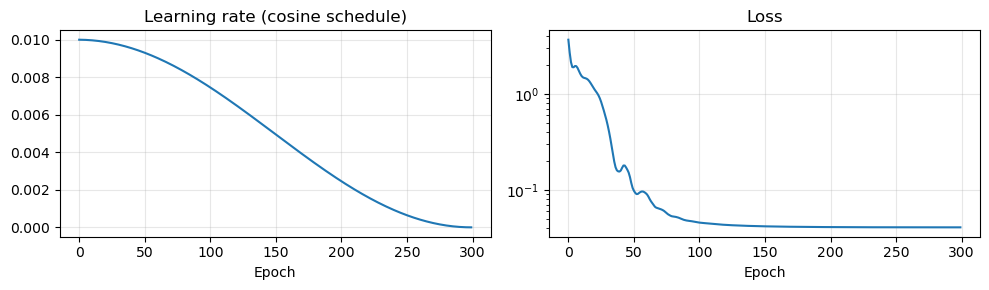

In [8]:
model  = make_model()
optim  = torch.optim.Adam(model.parameters(), lr=1e-2)

# Cosine annealing: lr decays from initial value to 0 over T_max epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=300)

lrs, losses_sched = [], []
for epoch in range(300):
    optim.zero_grad()
    loss = loss_fn(model(x_q), y_q)
    loss.backward()
    optim.step()
    scheduler.step()   # update lr after each epoch
    lrs.append(optim.param_groups[0]["lr"])
    losses_sched.append(loss.item())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(lrs)
ax1.set_title("Learning rate (cosine schedule)")
ax1.set_xlabel("Epoch")
ax2.plot(losses_sched)
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_yscale("log")
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Other useful schedulers (shown conceptually, but not run):

# StepLR: multiply lr by gamma every step_size epochs
# torch.optim.lr_scheduler.StepLR(optim, step_size=100, gamma=0.5)

# ReduceLROnPlateau: lower lr when loss stops improving
# torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=20, factor=0.5)

# OneCycleLR: warm-up then cosine decay -popular for fast training
# torch.optim.lr_scheduler.OneCycleLR(optim, max_lr=1e-2, total_steps=1000)

print("Scheduler constructors shown as comments above.")

Scheduler constructors shown as comments above.


---
## Tips for Stable Training

| Situation | Tip |
|-----------|-----|
| Loss explodes early | Reduce learning rate, add gradient clipping |
| Loss never decreases | Increase learning rate, check data preprocessing |
| Model overfits | Add weight decay (`AdamW`), reduce model capacity |
| Slow convergence | Try Adam/AdamW instead of SGD, or use a scheduler |
| NaN loss | Check for zero-division, log(0), or very large activations |

In [10]:
# Gradient clipping -prevents exploding gradients
model  = make_model()
optim  = torch.optim.Adam(model.parameters(), lr=1e-3)

# In your training loop, add this line between backward() and step():
optim.zero_grad()
loss = loss_fn(model(x_q), y_q)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # clip here
optim.step()

print("Training step with gradient clipping completed.")

Training step with gradient clipping completed.


---
## Summary

| Concept | Code |
|---------|------|
| Compute gradients | `loss.backward()` |
| Clear old gradients | `optimizer.zero_grad()` |
| Update parameters | `optimizer.step()` |
| SGD with momentum | `optim.SGD(params, lr=…, momentum=0.9)` |
| Adam | `optim.Adam(params, lr=1e-3)` |
| AdamW (preferred) | `optim.AdamW(params, lr=1e-3, weight_decay=1e-4)` |
| Cosine schedule | `lr_scheduler.CosineAnnealingLR(optim, T_max=…)` |
| Gradient clipping | `clip_grad_norm_(params, max_norm=1.0)` |
| Skip grad tracking | `with torch.no_grad(): …` |

**Next:** [05_mlp_regression.ipynb](05_mlp_regression.ipynb). We show how to train a neural network (MLP) from scratch. We demonstrate how this can be used to approximate a given 2D function (regression).